<a href="https://colab.research.google.com/github/matheeshagit/FDM-Mini-Project/blob/main/Diabitic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('diabetic_data.csv', na_values='?')
data.head()

/tmp/ipykernel_1840/1090213076.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('diabetic_data.csv', na_values='?')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
data.columns = data.columns.str.replace('-', '_')
data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

## Check Missing Values

In [4]:
data.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
data.isnull().mean() * 100

,0
encounter_id,0.000000
patient_nbr,0.000000
race,2.233555
gender,0.000000
age,0.000000
weight,96.858479
admission_type_id,0.000000
discharge_disposition_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000


## Identify the Data Types of each column

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Checking the Numerical Data columns including Five Number Summary

In [7]:
data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
data.duplicated().sum()

np.int64(0)

In [10]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.3 MB/s eta 0:00:00


/tmp/ipykernel_1840/272675253.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [11]:
profile = ProfileReport(data, explorative=True, minimal=True)
profile.to_file('profile.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:06<00:00,  7.24it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Check near zero variance columns

In [12]:
for col in data.columns:
  print(f'{col}: ', data[col].value_counts(normalize=True).max())

encounter_id:  9.82646463455378e-06
patient_nbr:  0.00039305858538215123
race:  0.7648678801523725
gender:  0.5375862272271682
age:  0.25615628009354796
weight:  0.4178917735376916
admission_type_id:  0.5305308256195586
discharge_disposition_id:  0.5918872707977124
admission_source_id:  0.564962757699035
time_in_hospital:  0.1744787060511369
payer_code:  0.527377662168753
medical_specialty:  0.2824362660902793
num_lab_procedures:  0.03152329854764853
num_procedures:  0.458424228131203
num_medications:  0.059803863765894305
number_outpatient:  0.8355148084822043
number_emergency:  0.8881453530648743
number_inpatient:  0.6645638032348722
diag_1:  0.06744311759791637
diag_2:  0.0665825181445251
diag_3:  0.11515501828727465
number_diagnoses:  0.4861545113299137
max_glu_serum:  0.48578376356154135
A1Cresult:  0.48278293571512515
metformin:  0.8035886248845391
repaglinide:  0.9848770709274217
nateglinide:  0.9930919953619087
chlorpropamide:  0.9991549240414284
glimepiride:  0.948990822082031

Boxplots to identify outliers

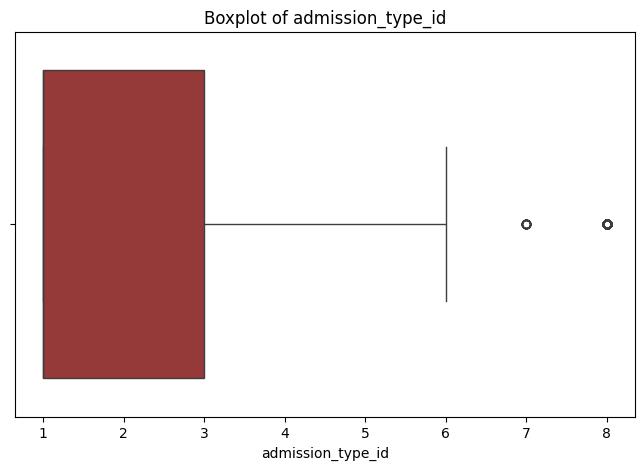

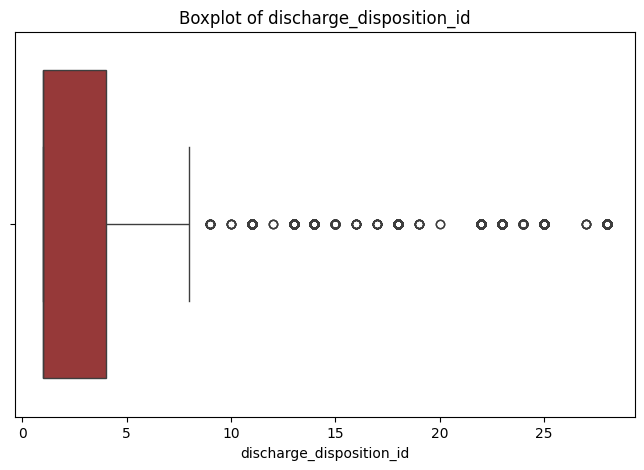

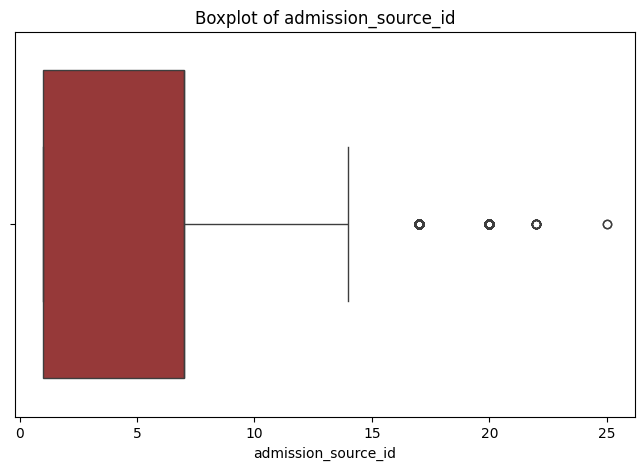

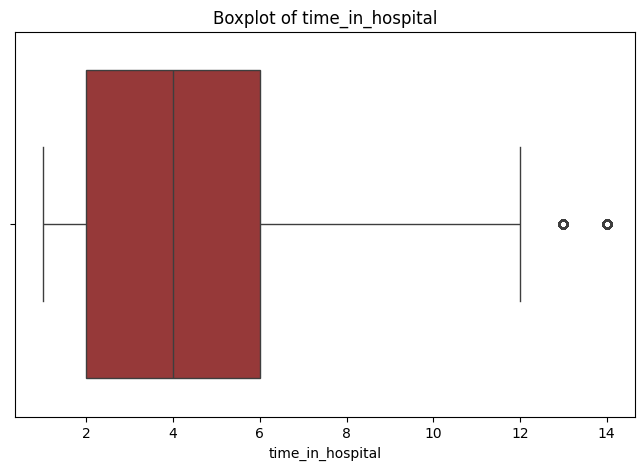

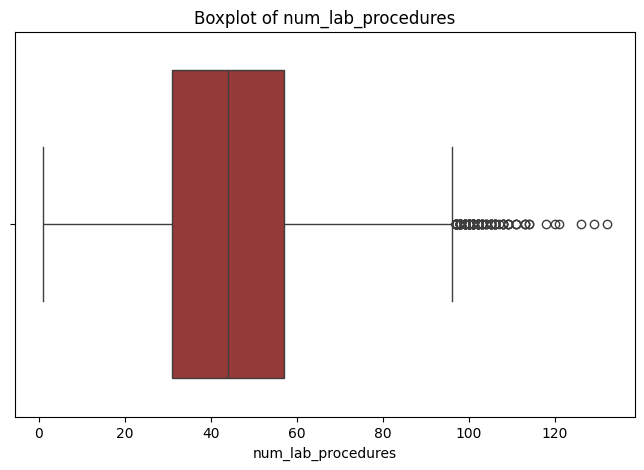

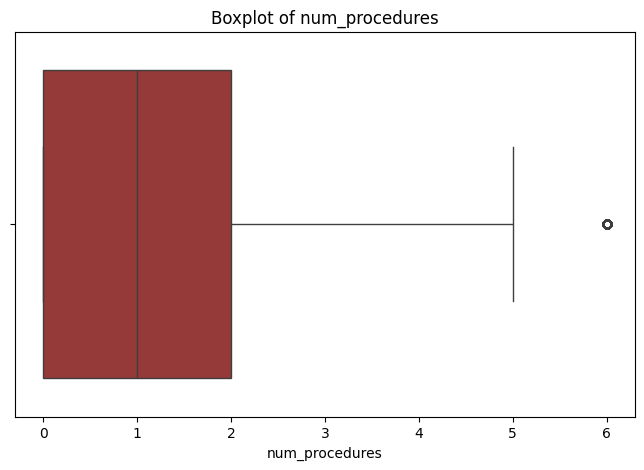

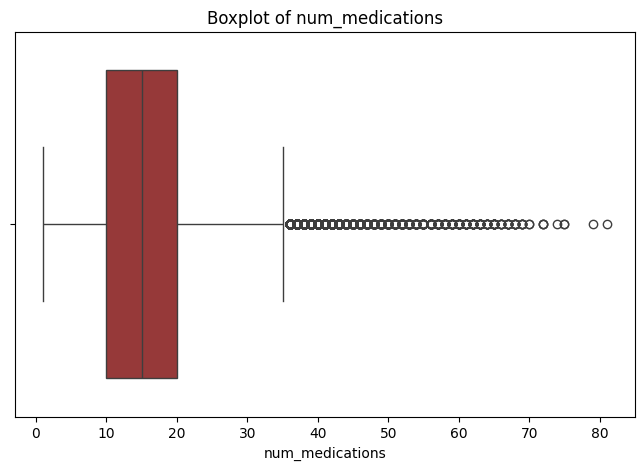

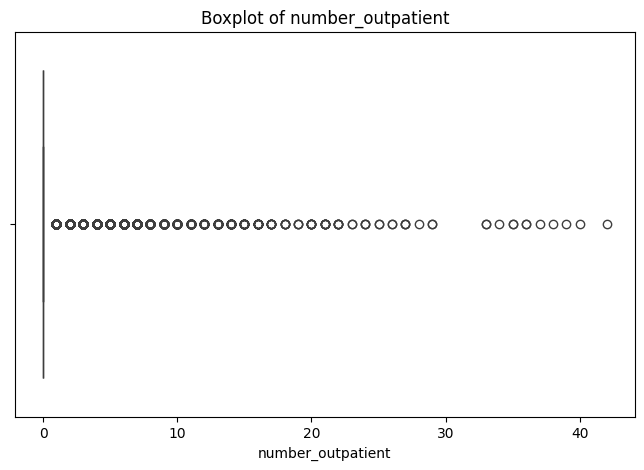

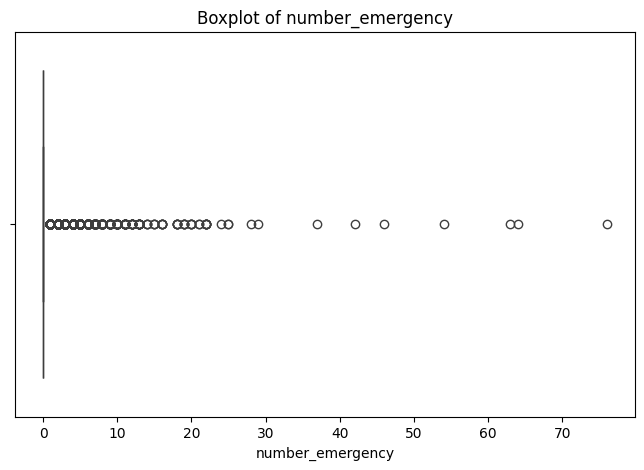

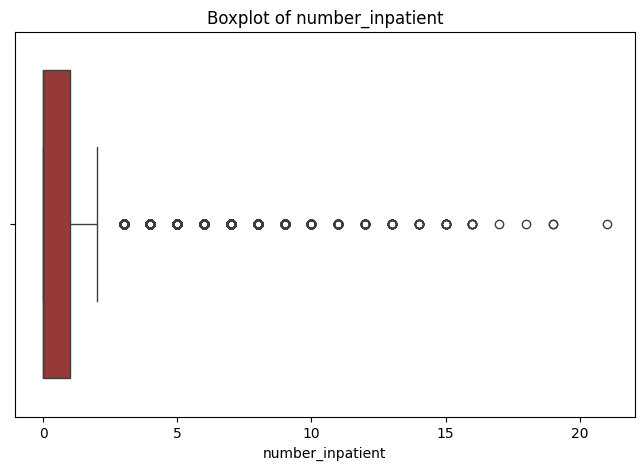

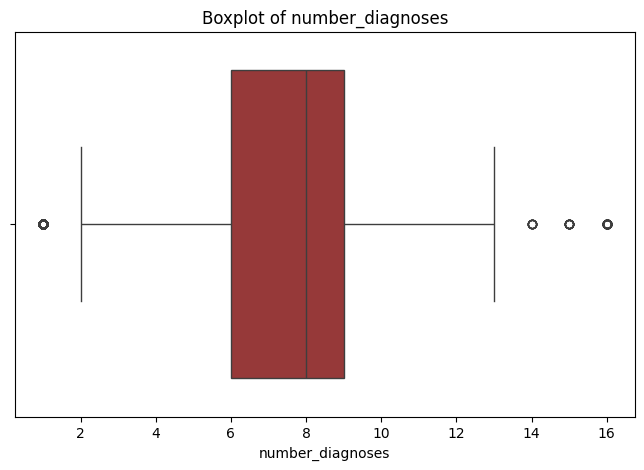

In [13]:
num_cols = data.select_dtypes(include=np.number).columns
id_cols = ['encounter_id', 'patient_nbr']

for col in num_cols:
  if col not in id_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[col], color='brown' )
    plt.title(f'Boxplot of {col}')
    plt.show()
    print()

Distribution of Numerical Cols

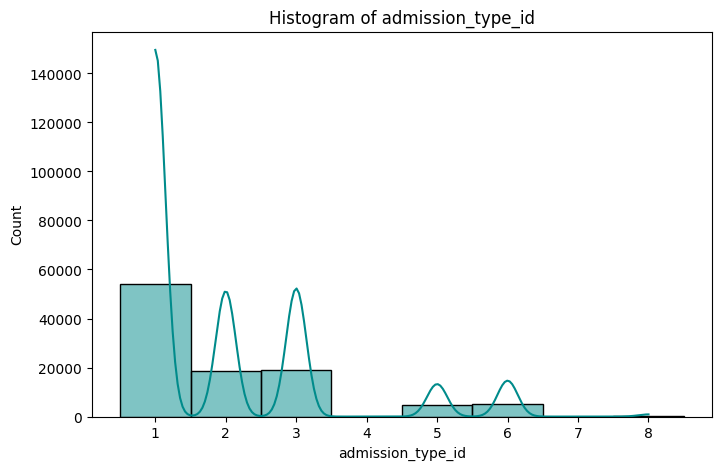

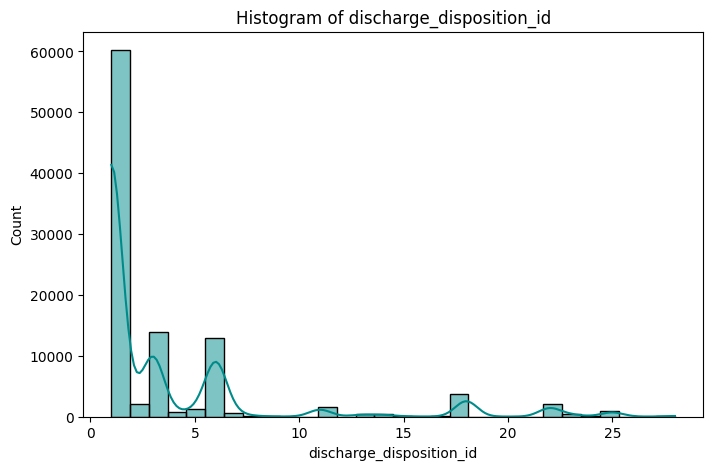

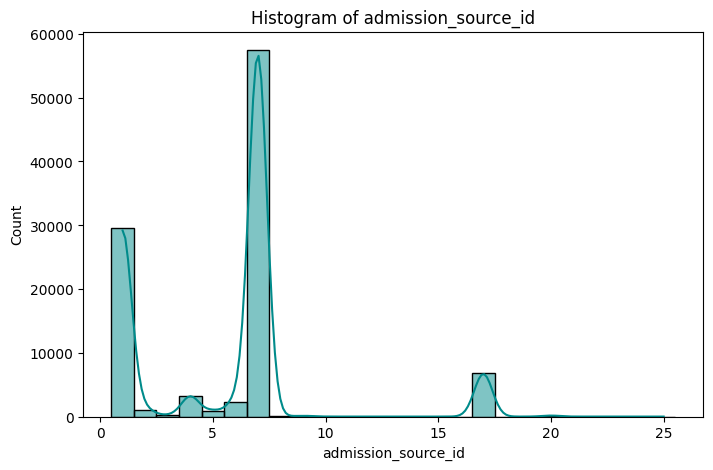

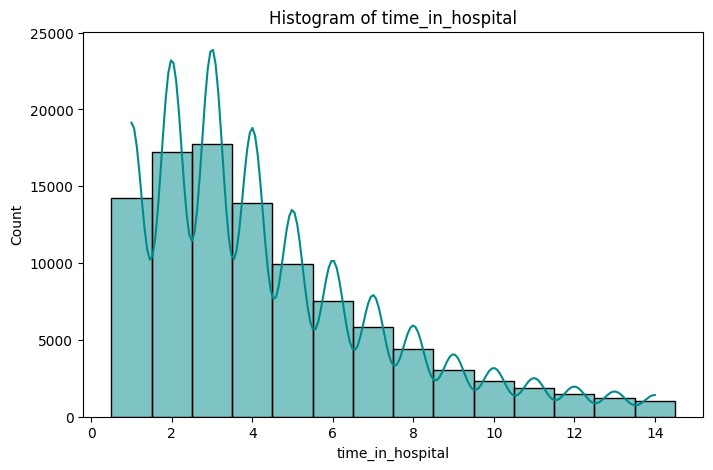

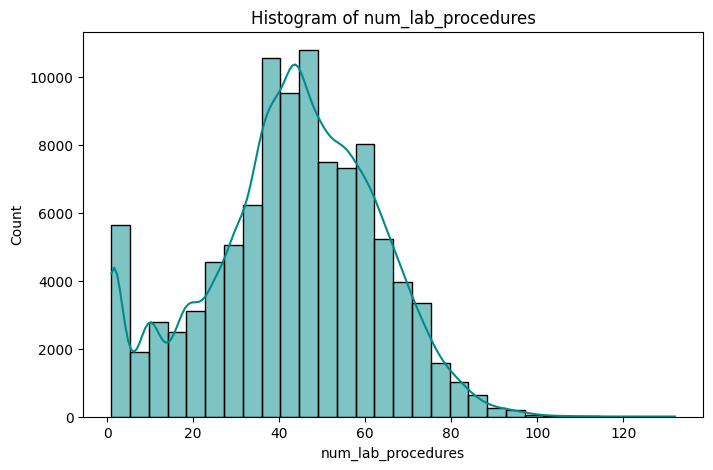

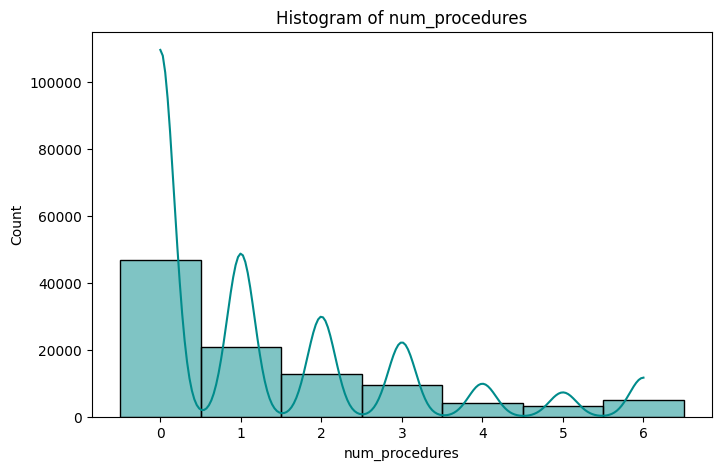

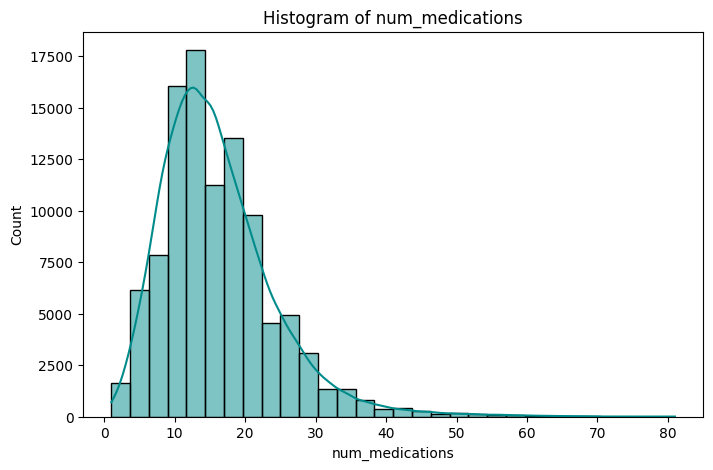

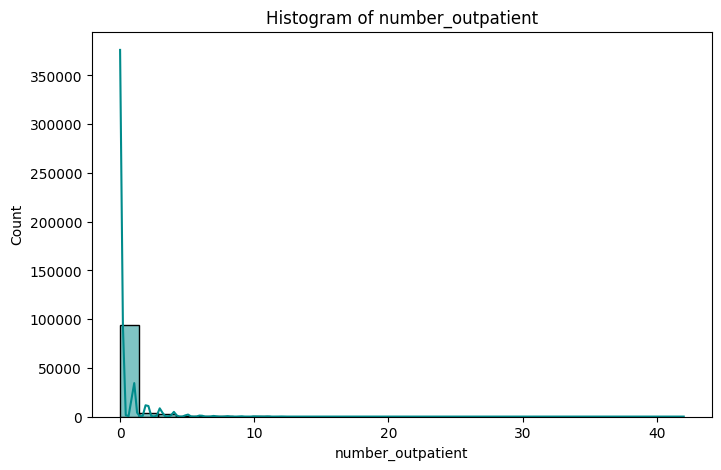

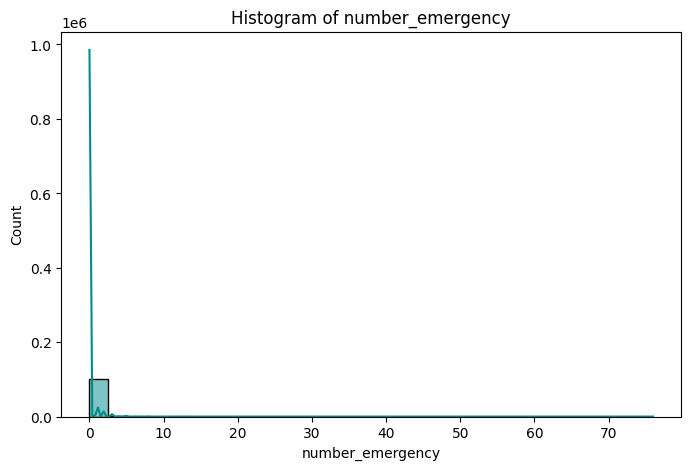

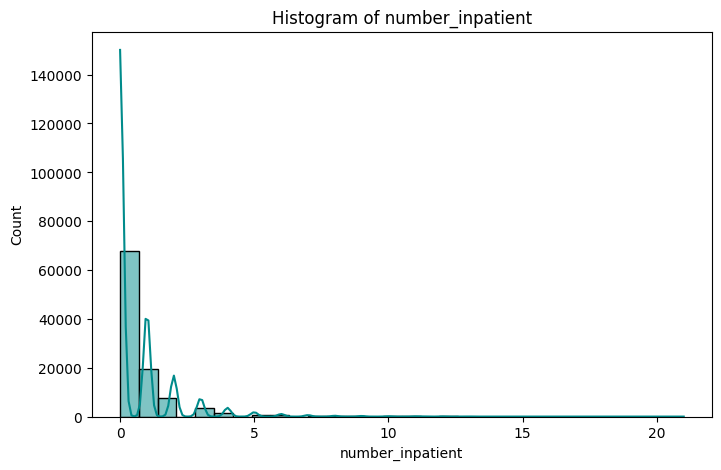

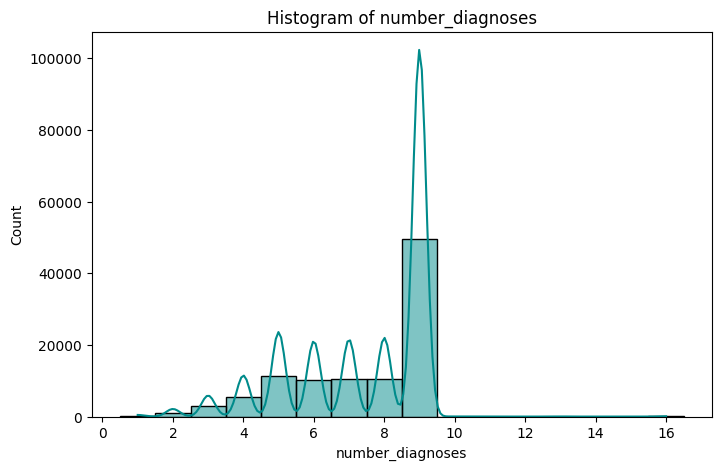

In [14]:
from scipy.stats import kde
for col in num_cols:
  if col not in id_cols:
    plt.figure(figsize=(8,5))

    n_unq = data[col].nunique()

    if n_unq < 20:
      sns.histplot(data[col], discrete=True, kde=True, color='darkcyan')
    else:
      sns.histplot(data[col], bins=30, kde=True, color='darkcyan')
    plt.title(f'Histogram of {col}')
    plt.show()
    print()

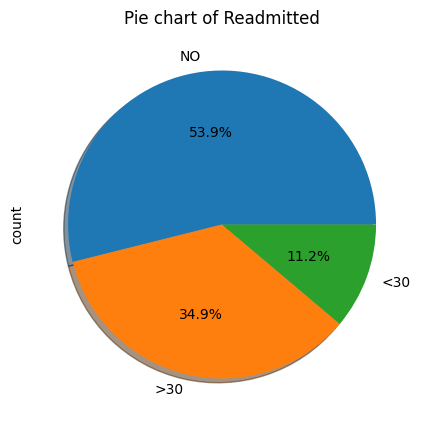

In [15]:
plt.figure(figsize=(5,5))
data['readmitted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    shadow=True
)
plt.title('Pie chart of Readmitted')
plt.show()

##Preprocessing

In [18]:
from sklearn.model_selection import train_test_split

Droping ID columns and near zero variance columns

In [16]:
#ID columns
rm_cols=['encounter_id', 'patient_nbr']

for col in data.columns:
  dominance = data[col].value_counts(normalize=True).max()
  if dominance > 0.99:
    rm_cols.append(col)
print(rm_cols)

data = data.drop(rm_cols, axis=1)

print('\nColumns:', data.columns)

['encounter_id', 'patient_nbr', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_pioglitazone', 'metformin_rosiglitazone', 'metformin_pioglitazone']

Columns: Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
       'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


Removing columns with high null value rate

In [17]:
null_cols=['weight','payer_code']

data = data.drop(null_cols, axis=1)

print(data.head())

              race  gender      age  admission_type_id  \
0        Caucasian  Female   [0-10)                  6   
1        Caucasian  Female  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)                  1   
3        Caucasian    Male  [30-40)                  1   
4        Caucasian    Male  [40-50)                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital  \
0                        25                    1                 1   
1                         1                    7                 3   
2                         1                    7                 2   
3                         1                    7                 2   
4                         1                    7                 1   

          medical_specialty  num_lab_procedures  num_procedures  ...  \
0  Pediatrics-Endocrinology                  41               0  ...   
1                       NaN                  59               0  ...   
2             

In [19]:
data['readmitted_binary'] = (data['readmitted'] == '<30').astype(int)

X = data.drop(['readmitted', 'readmitted_binary'], axis=1)
y = data['readmitted_binary']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train shape:{X_train.shape}, Test Shape:{X_test.shape}')

Train shape:(81412, 30), Test Shape:(20354, 30)
